<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#0F2E2B; padding: 40px 44px; border-radius: 14px; margin-bottom: 8px; position:relative; overflow:hidden;">
  <div style="font-size:150px; font-weight:900; color:rgba(255,255,255,0.04); position:absolute; top:-30px; right:24px; line-height:1; letter-spacing:-0.05em;">01</div>
  <div style="font-size:10px; color:#5FCDAA; letter-spacing:0.3em; text-transform:uppercase; margin-bottom:18px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:38px; font-weight:800; color:#F5F3EC; letter-spacing:-0.02em; line-height:1.1; margin-bottom:8px;">Home Credit <span style="color:#5FCDAA;">Default Risk.</span></div>
  <div style="font-size:12px; color:#E08A6D; font-weight:500; margin-bottom:28px; letter-spacing:0.05em;">Notebook 1 &mdash; Exploratory Data Analysis</div>
  <div style="display:flex; gap:56px;">
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Group 1</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Rui Ferreira, 20250473<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Course</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">MLOps<br>MSc Data Science &amp; Advanced Analytics<br>NOVA Information Management School</div>
    </div>
  </div>
</div>

## <span style="color:#1B7A6E;"><b>Table of Contents</b></span>
- [1. Setup & Imports](#1-setup--imports)
- [2. First Look](#2-first-look)
- [3. TARGET Analysis](#3-target-analysis-class-imbalance)
- [4. Missing Values](#4-missing-values-complete-map)
- [5. Numerical Variables](#5-numerical-variables--distributions--outliers)
- [6. Categorical Variables](#6-categorical-variables)
    - [6.1. Cardinality](#61-cardinality)
    - [6.2. Categorical Anomalies](#62-categorical-anomalies)
    - [6.3. Default Rate per Category](#63-default-rate-per-category)
- [7. Correlations](#7-correlations)
- [8. Multicollinearity](#8-multicollinearity)
- [9. Data Leakage & Sanity Checks](#9-data-leakage--sanity-checks)
    - [9.1. Train/Test Schema Parity](#91-traintest-schema-parity)
    - [9.2. Near-Perfect Predictors](#92-suspicious-near-perfect-predictors)
    - [9.3. Logical Range Checks](#93-logical-range-checks)
- [10. Secondary Tables](#10-secondary-tables-analysis)
- [11. Conclusions](#11-conclusions--decisions-for-the-pipeline)

## About the project

This notebook is the first stage of an end-to-end **MLOps pipeline** that simulates the real-world process of deploying a credit-risk model. The underlying business problem (Home Credit) is about **broadening financial inclusion** for people with little or no credit history, by predicting their ability to repay a loan &mdash; so that creditworthy applicants are not wrongly rejected.

**Task:** binary classification &mdash; predict `TARGET`
- `TARGET = 1` &rarr; client had repayment difficulties (default)
- `TARGET = 0` &rarr; client repaid normally

**Main dataset:** `application_train.csv` (~307k rows, 122 columns)

<a id="setup"></a>
## 1. Setup & imports

We load the standard data-science stack and define a single cohesive palette (**Deep Teal & Coral**) plus global matplotlib styling, so every figure in the notebook shares the same visual language.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

TEAL   = '#1B7A6E'   
CORAL  = '#E07856'   
GOLD   = '#E0A458'  
SLATE  = '#3D5A6C'   
SKY    = '#6FB3C9'   
SAGE   = '#8FB996'   
INK    = '#0F2E2B'   

PALETTE = [TEAL, CORAL, GOLD, SLATE, SKY, SAGE]

CMAP_DIV = LinearSegmentedColormap.from_list('teal_coral', [TEAL, '#F5F3EC', CORAL])

CMAP_SEQ = LinearSegmentedColormap.from_list('sage_coral', [SAGE, GOLD, CORAL])

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#D9D4C7',
    'axes.linewidth'    : 1.0,
    'axes.grid'         : True,
    'grid.color'        : '#ECE8DD',
    'grid.linewidth'    : 0.8,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : INK,
    'axes.labelcolor'   : SLATE,
    'axes.labelsize'    : 10,
    'xtick.color'       : SLATE,
    'ytick.color'       : SLATE,
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'legend.frameon'    : False,
    'figure.dpi'        : 110,
})
sns.set_palette(PALETTE)

DATA_PATH = '../data/01_raw/'

print('Setup complete - palette: Deep Teal & Coral')

Setup complete - palette: Deep Teal & Coral


<a id="first-look"></a>
## 2. First look

Shape, column types and a quick sample to get oriented before any deeper analysis.

In [2]:
train = pd.read_csv(DATA_PATH + 'application_train.csv')
test  = pd.read_csv(DATA_PATH + 'application_test.csv')

print(f'Train shape : {train.shape}  ({train.shape[0]:,} rows, {train.shape[1]} columns)')
print(f'Test shape  : {test.shape}   ({test.shape[0]:,} rows, {test.shape[1]} columns)')
print(f'\nColumns only in train (TARGET): {set(train.columns) - set(test.columns)}')

Train shape : (307511, 122)  (307,511 rows, 122 columns)
Test shape  : (48744, 121)   (48,744 rows, 121 columns)

Columns only in train (TARGET): {'TARGET'}


In [3]:
train.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,...,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,...,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00


In [4]:
dtype_counts = train.dtypes.value_counts()
print('Column types:')
for dtype, count in dtype_counts.items():
    print(f'  {str(dtype):10s}: {count} columns')

num_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

num_cols = [c for c in num_cols if c not in ['SK_ID_CURR', 'TARGET']]

print(f'\nNumerical  : {len(num_cols)}')
print(f'Categorical: {len(cat_cols)}')

Column types:
  float64   : 65 columns
  int64     : 41 columns
  object    : 16 columns

Numerical  : 104
Categorical: 16


<a id="target"></a>
## 3. TARGET analysis (class imbalance)

The target is binary. Before anything else we check how (im)balanced it is, because that decision drives our choice of metric and resampling strategy downstream.

In [5]:
target_counts = train['TARGET'].value_counts()
target_pct    = train['TARGET'].value_counts(normalize=True) * 100

print('TARGET Distribution:')
print(f'  0 (Paid)     : {target_counts[0]:>7,}  ({target_pct[0]:.1f}%)')
print(f'  1 (Default)  : {target_counts[1]:>7,}  ({target_pct[1]:.1f}%)')
print(f'\n  Imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')
print('\n  HIGH CLASS IMBALANCE — use AUC-ROC as main metric!')
print('   Accuracy would be misleading (a model that always predicts 0 would have ~92% accuracy)')

TARGET Distribution:
  0 (Paid)     : 282,686  (91.9%)
  1 (Default)  :  24,825  (8.1%)

  Imbalance ratio: 11.4:1

  HIGH CLASS IMBALANCE — use AUC-ROC as main metric!
   Accuracy would be misleading (a model that always predicts 0 would have ~92% accuracy)


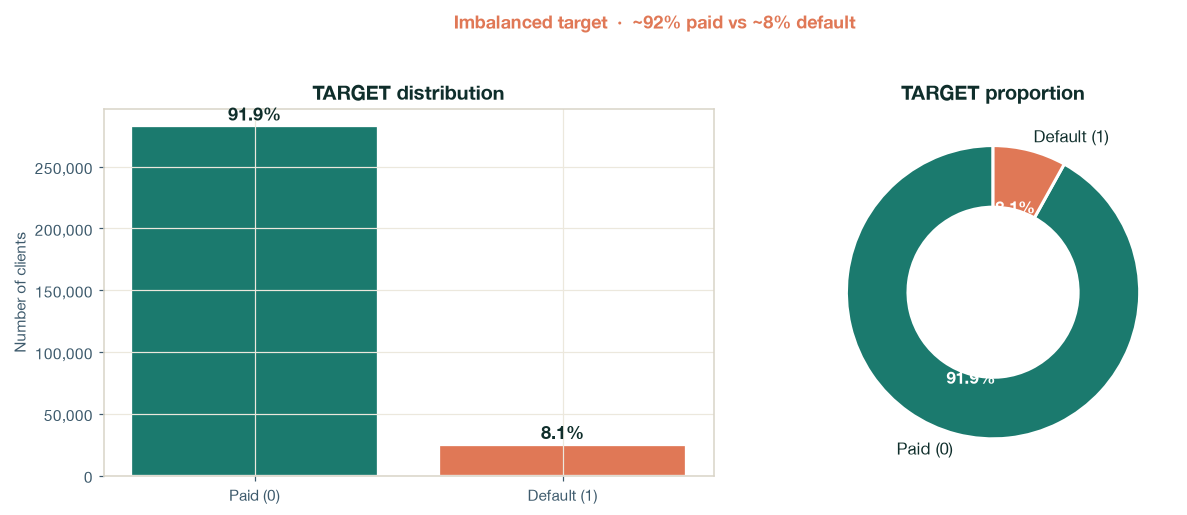

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))


bars = axes[0].bar(['Paid (0)', 'Default (1)'], target_counts.values,
                   color=[TEAL, CORAL], edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold',
                 fontsize=12, color=INK)
axes[0].set_title('TARGET distribution', fontsize=13)
axes[0].set_ylabel('Number of clients')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie / donut
wedges, _, autotexts = axes[1].pie(
    target_counts.values, labels=['Paid (0)', 'Default (1)'],
    colors=[TEAL, CORAL], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.42},
    textprops={'fontsize': 11, 'color': INK})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
axes[1].set_title('TARGET proportion', fontsize=13)

fig.suptitle('Imbalanced target  ·  ~92% paid vs ~8% default',
             fontsize=12, y=1.03, color=CORAL, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="missing"></a>
## 4. Missing values complete map

Many columns in this dataset are sparsely populated. We map missingness across all columns and bucket them by severity, which directly informs the data-cleaning pipeline.

In [7]:
# Calculate missing values per column
missing = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_pct'  : train.isnull().mean() * 100
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]

print(f'Columns WITH missing values: {len(missing)} of {train.shape[1]}')
print(f'Columns WITHOUT missing values: {train.shape[1] - len(missing)}')
print(f'\nTop 10 columns with most missings:')
print(missing.head(10).to_string())

# Categorize by severity
low    = (missing['missing_pct'] < 10).sum()
medium = ((missing['missing_pct'] >= 10) & (missing['missing_pct'] < 50)).sum()
high   = (missing['missing_pct'] >= 50).sum()
print(f'\nMissing value severity:')
print(f'  Low    (<10%)  : {low} columns')
print(f'  Medium (10-50%): {medium} columns')
print(f'  High   (>50%)  : {high} columns — consider removing')

Columns WITH missing values: 67 of 122
Columns WITHOUT missing values: 55

Top 10 columns with most missings:
                          missing_count  missing_pct
COMMONAREA_AVG                   214865        69.87
COMMONAREA_MODE                  214865        69.87
COMMONAREA_MEDI                  214865        69.87
NONLIVINGAPARTMENTS_MEDI         213514        69.43
NONLIVINGAPARTMENTS_MODE         213514        69.43
NONLIVINGAPARTMENTS_AVG          213514        69.43
FONDKAPREMONT_MODE               210295        68.39
LIVINGAPARTMENTS_AVG             210199        68.35
LIVINGAPARTMENTS_MEDI            210199        68.35
LIVINGAPARTMENTS_MODE            210199        68.35

Missing value severity:
  Low    (<10%)  : 10 columns
  Medium (10-50%): 16 columns
  High   (>50%)  : 41 columns — consider removing


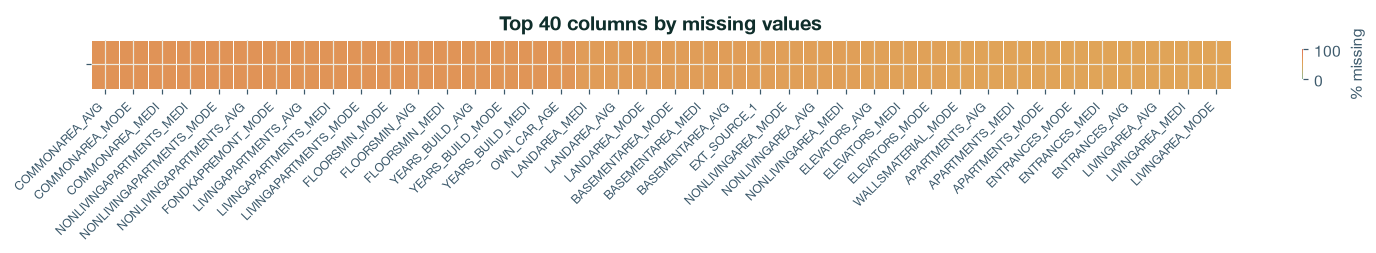

In [8]:
# Heatmap of the 40 columns with most missing values
top_missing_cols = missing.head(40).index.tolist()

fig, ax = plt.subplots(figsize=(14, 2.4))
sns.heatmap(missing.head(40)[['missing_pct']].T,
            annot=False, cmap=CMAP_SEQ, vmin=0, vmax=100,
            cbar_kws={'label': '% missing', 'shrink': 0.6},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Top 40 columns by missing values', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([], rotation=0)
plt.tight_layout()
plt.savefig('../data/08_reporting/missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

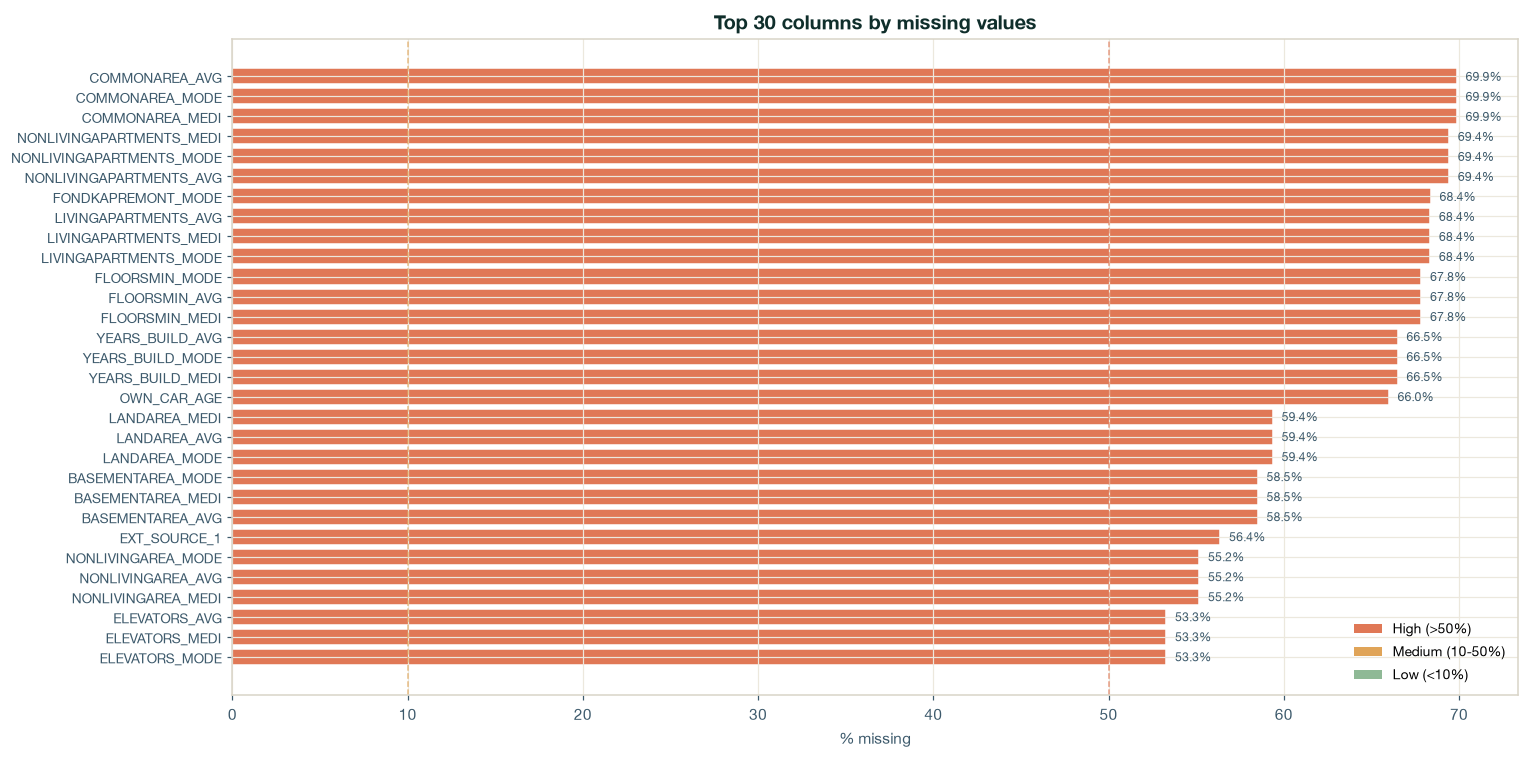

In [9]:
# Horizontal bar of the top 30 columns by missingness
fig, ax = plt.subplots(figsize=(14, 7))

top30 = missing.head(30)
colors = [CORAL if x >= 50 else GOLD if x >= 10 else SAGE for x in top30['missing_pct']]

bars = ax.barh(range(len(top30)), top30['missing_pct'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=9)
ax.axvline(x=50, color=CORAL, linestyle='--', alpha=0.7, linewidth=1)
ax.axvline(x=10, color=GOLD,  linestyle='--', alpha=0.7, linewidth=1)
ax.set_xlabel('% missing')
ax.set_title('Top 30 columns by missing values', fontsize=13)

from matplotlib.patches import Patch
legend = [Patch(facecolor=CORAL, label='High (>50%)'),
          Patch(facecolor=GOLD,  label='Medium (10-50%)'),
          Patch(facecolor=SAGE,  label='Low (<10%)')]
ax.legend(handles=legend, fontsize=9, loc='lower right')

for i, (bar, val) in enumerate(zip(bars, top30['missing_pct'])):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8, color=SLATE)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/08_reporting/missing_values_bar.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="numeric"></a>
## 5. Numerical variables — distributions & outliers


We inspect the key numerical features, convert the `DAYS_*` columns into intuitive units, flag the `DAYS_EMPLOYED` sentinel value, and compare distributions across the two target classes.

In [10]:
# Descriptive statistics of the most relevant numerical features
key_num_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

# Filter only existing columns
key_num_cols = [c for c in key_num_cols if c in train.columns]

desc = train[key_num_cols].describe().T
desc['skewness'] = train[key_num_cols].skew()
desc['kurtosis'] = train[key_num_cols].kurtosis()
print('Descriptive statistics for key columns:')
desc[['count','mean','std','min','50%','max','skewness','kurtosis']]

Descriptive statistics for key columns:


,count,mean,std,min,50%,max,skewness,kurtosis
AMT_INCOME_TOTAL,307511.00,168797.92,237123.15,25650.00,147150.00,117000000.00,391.56,191786.55
AMT_CREDIT,307511.00,599026.00,402490.78,45000.00,513531.00,4050000.00,1.23,1.93
AMT_ANNUITY,307499.00,27108.57,14493.74,1615.50,24903.00,258025.50,1.58,7.71
AMT_GOODS_PRICE,307233.00,538396.21,369446.46,40500.00,450000.00,4050000.00,1.35,2.43
DAYS_BIRTH,307511.00,-16037.00,4363.99,-25229.00,-15750.00,-7489.00,-0.12,-1.05
DAYS_EMPLOYED,307511.00,63815.05,141275.77,-17912.00,-1213.00,365243.00,1.66,0.77
DAYS_REGISTRATION,307511.00,-4986.12,3522.89,-24672.00,-4504.00,0.00,-0.59,-0.32
DAYS_ID_PUBLISH,307511.00,-2994.20,1509.45,-7197.00,-3254.00,0.00,0.35,-1.11
CNT_CHILDREN,307511.00,0.42,0.72,0.00,0.00,19.00,1.97,7.90
CNT_FAM_MEMBERS,307509.00,2.15,0.91,1.00,2.00,20.00,0.99,2.80


In [11]:
# DAYS_BIRTH: convert to age in years
train['AGE_YEARS'] = -train['DAYS_BIRTH'] / 365

# DAYS_EMPLOYED: anomalous values (365243 = sentinel value for 'not employed')
print('DAYS_EMPLOYED — suspicious unique values:')
print(f'  Value 365243 (sentinel): {(train["DAYS_EMPLOYED"] == 365243).sum():,} occurrences')
print(f'  This corresponds to {(train["DAYS_EMPLOYED"] == 365243).mean()*100:.1f}% of the dataset')
print('  >> THESE MUST BE REPLACED WITH NaN IN DATA CLEANING!')

# Create clean version for EDA
train['DAYS_EMPLOYED_CLEAN'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)
train['EMPLOYED_YEARS'] = -train['DAYS_EMPLOYED_CLEAN'] / 365

DAYS_EMPLOYED — suspicious unique values:
  Value 365243 (sentinel): 55,374 occurrences
  This corresponds to 18.0% of the dataset
  >> THESE MUST BE REPLACED WITH NaN IN DATA CLEANING!


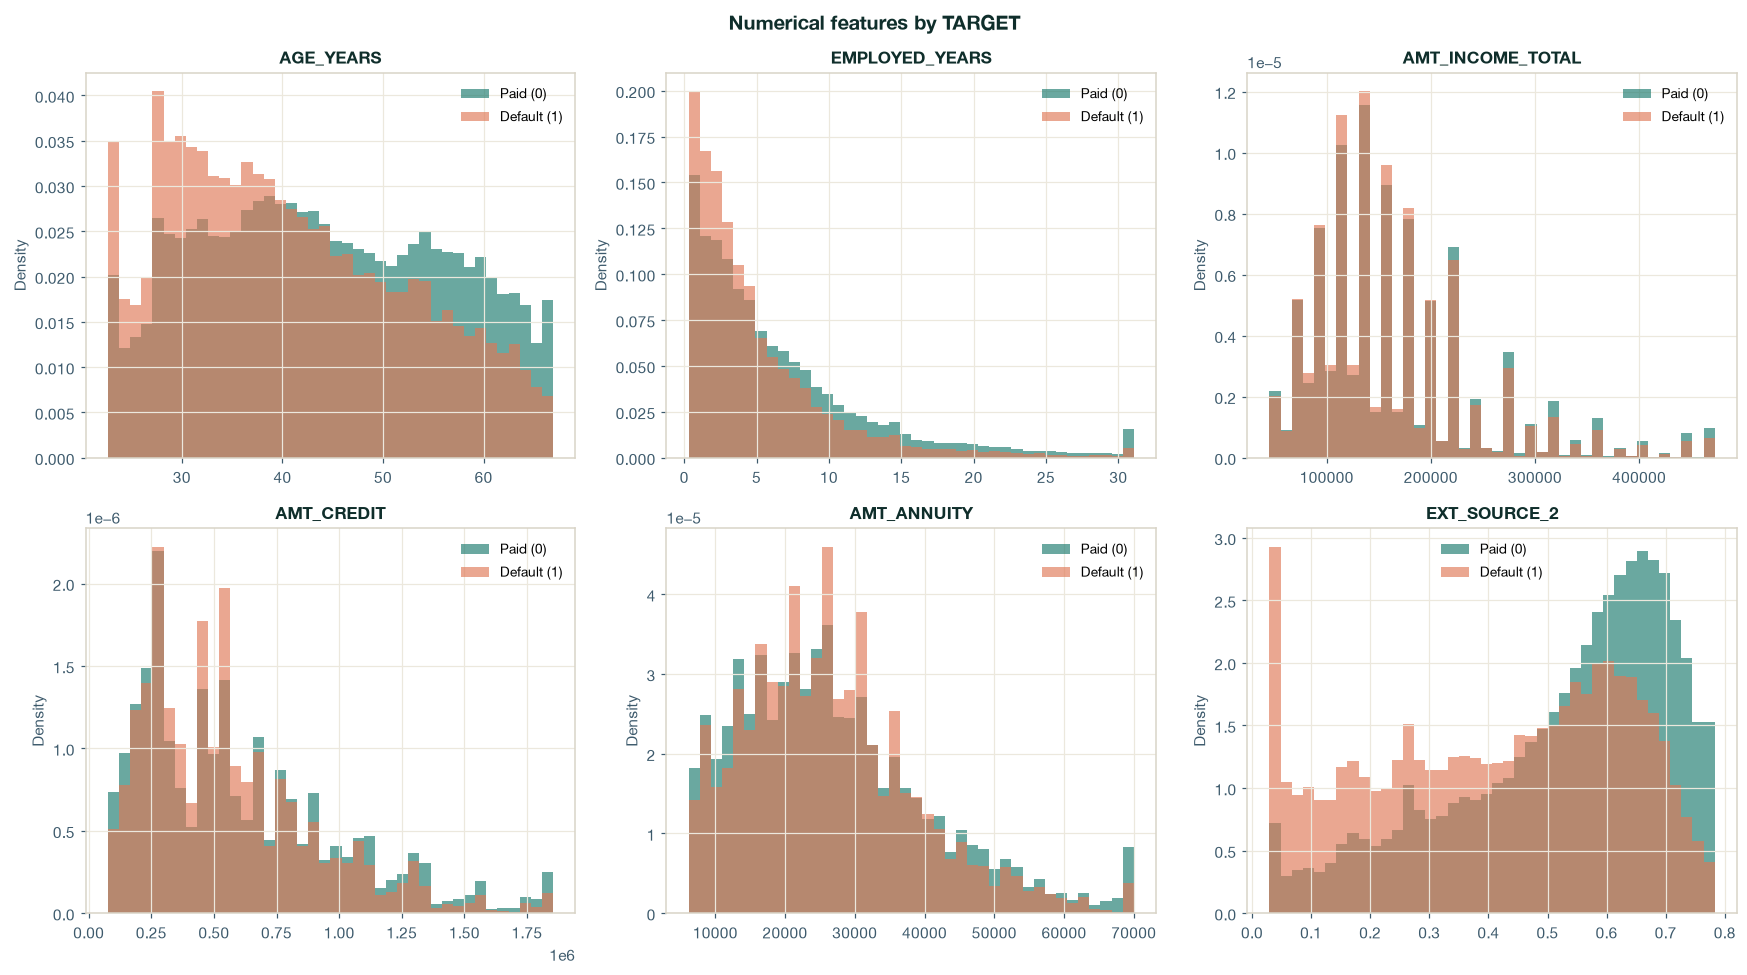

In [12]:
# Distribution of the most important numerical variables by TARGET
plot_cols = ['AGE_YEARS', 'EMPLOYED_YEARS', 'AMT_INCOME_TOTAL',
             'AMT_CREDIT', 'AMT_ANNUITY', 'EXT_SOURCE_2']
plot_cols = [c for c in plot_cols if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if i >= len(axes):
        break
    data0 = train[train['TARGET'] == 0][col].dropna()
    data1 = train[train['TARGET'] == 1][col].dropna()

    # Clip extreme outliers for visualization
    p1, p99 = train[col].dropna().quantile([0.01, 0.99])
    data0 = data0.clip(p1, p99)
    data1 = data1.clip(p1, p99)

    axes[i].hist(data0, bins=40, alpha=0.65, color=TEAL,  label='Paid (0)',    density=True)
    axes[i].hist(data1, bins=40, alpha=0.65, color=CORAL, label='Default (1)', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numerical features by TARGET', fontsize=13, fontweight='bold', color=INK)
plt.tight_layout()
plt.savefig('../data/08_reporting/numeric_distributions_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

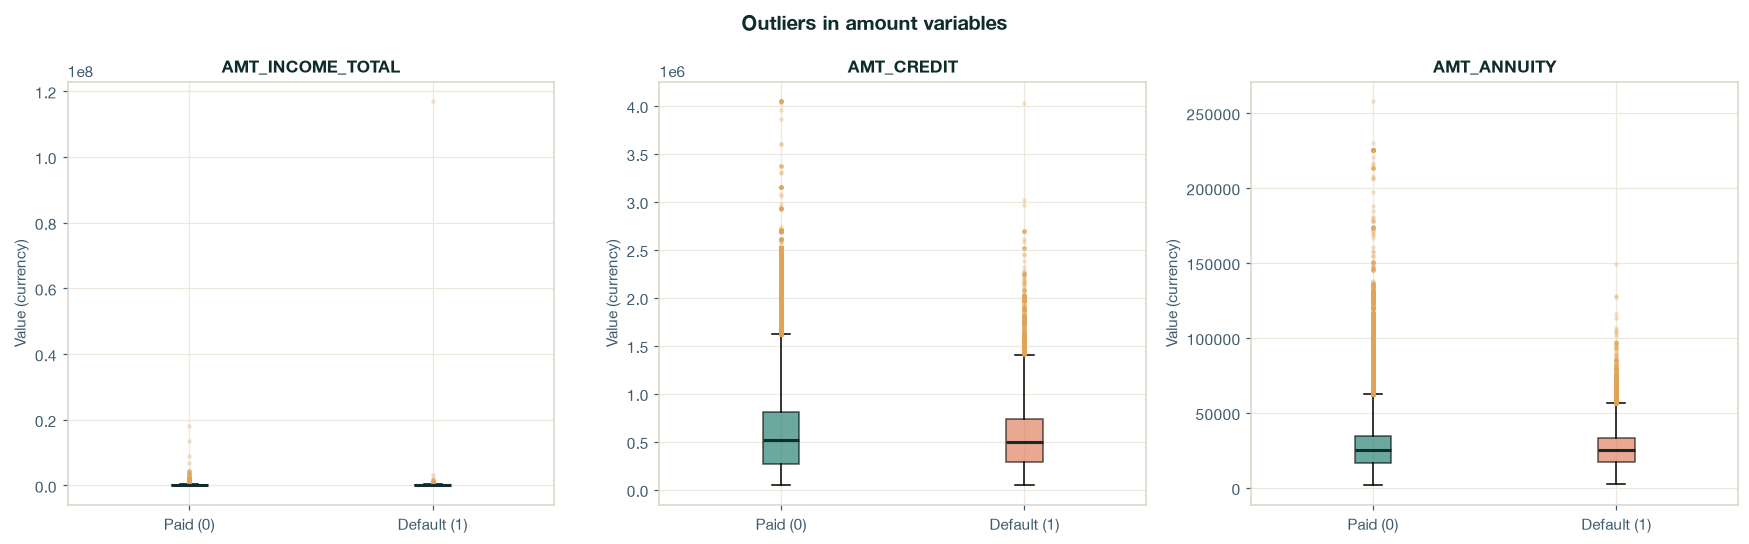

In [13]:
# Boxplots to spot outliers in the amount variables
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
amt_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
amt_cols = [c for c in amt_cols if c in train.columns]

for i, col in enumerate(amt_cols):
    bp = axes[i].boxplot([train[train['TARGET']==0][col].dropna(),
                          train[train['TARGET']==1][col].dropna()],
                         tick_labels=['Paid (0)', 'Default (1)'],
                         patch_artist=True,
                         medianprops=dict(color=INK, linewidth=2),
                         flierprops=dict(marker='o', markersize=3,
                                         markerfacecolor=GOLD, alpha=0.3,
                                         markeredgecolor='none'))
    for patch, c in zip(bp['boxes'], [TEAL, CORAL]):
        patch.set_facecolor(c); patch.set_alpha(0.65)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value (currency)')

fig.suptitle('Outliers in amount variables', fontsize=13, fontweight='bold', color=INK)
plt.tight_layout()
plt.savefig('../data/08_reporting/boxplots_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

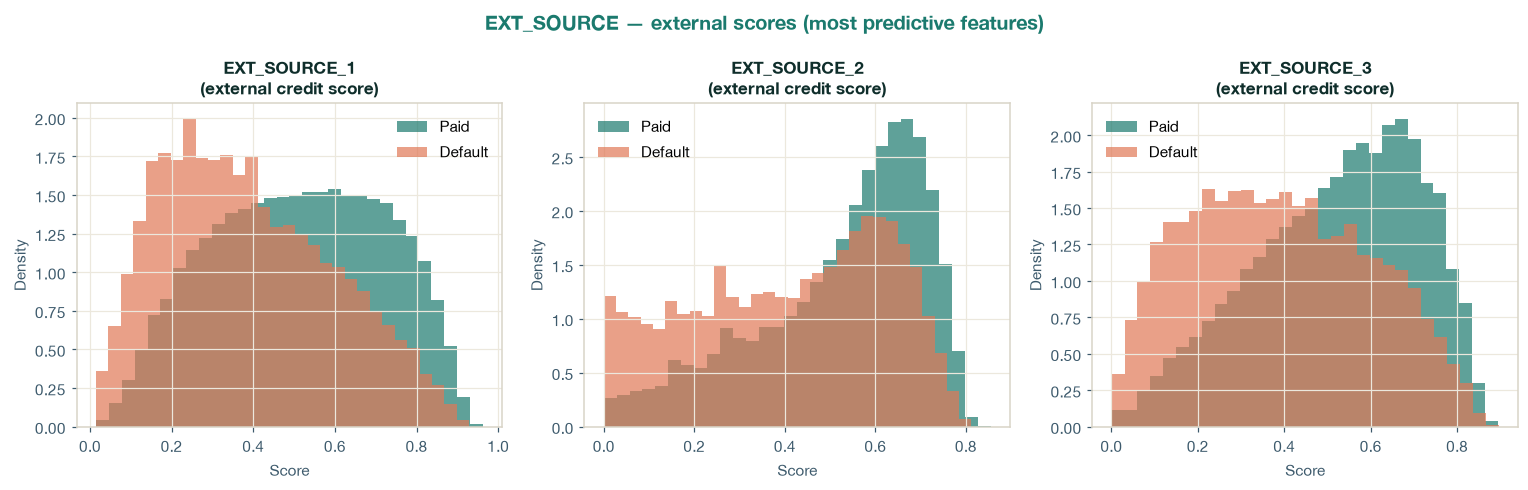

Clients in default show systematically lower EXT_SOURCE scores.


In [14]:
# EXT_SOURCE: among the most predictive features in the dataset
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_cols = [c for c in ext_cols if c in train.columns]

if ext_cols:
    fig, axes = plt.subplots(1, len(ext_cols), figsize=(14, 4.5))
    if len(ext_cols) == 1:
        axes = [axes]
    for i, col in enumerate(ext_cols):
        for tv, color, label in [(0, TEAL, 'Paid'), (1, CORAL, 'Default')]:
            data = train[train['TARGET'] == tv][col].dropna()
            axes[i].hist(data, bins=30, alpha=0.7, color=color, label=label, density=True)
        axes[i].set_title(f'{col}\n(external credit score)', fontsize=11)
        axes[i].legend()
        axes[i].set_xlabel('Score')
        axes[i].set_ylabel('Density')
    fig.suptitle('EXT_SOURCE — external scores (most predictive features)',
                 fontsize=13, fontweight='bold', color=TEAL)
    plt.tight_layout()
    plt.savefig('../data/08_reporting/ext_source_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Clients in default show systematically lower EXT_SOURCE scores.')

<a id="categorical"></a>
## 6. Categorical variables

We analyse the categorical features along three axes:

- **6.1 Cardinality** — how many distinct values each feature has, which drives the encoding strategy.
- **6.2 Anomalies** — invalid or placeholder categories that must be cleaned.
- **6.3 Default rate per category** — which groups carry above-average risk.

In [15]:
print('Categorical variables and number of unique categories:')
for col in cat_cols:
    n = train[col].nunique()
    print(f'  {col:40s}: {n} unique values')

Categorical variables and number of unique categories:
  NAME_CONTRACT_TYPE                      : 2 unique values
  CODE_GENDER                             : 3 unique values
  FLAG_OWN_CAR                            : 2 unique values
  FLAG_OWN_REALTY                         : 2 unique values
  NAME_TYPE_SUITE                         : 7 unique values
  NAME_INCOME_TYPE                        : 8 unique values
  NAME_EDUCATION_TYPE                     : 5 unique values
  NAME_FAMILY_STATUS                      : 6 unique values
  NAME_HOUSING_TYPE                       : 6 unique values
  OCCUPATION_TYPE                         : 18 unique values
  WEEKDAY_APPR_PROCESS_START              : 7 unique values
  ORGANIZATION_TYPE                       : 58 unique values
  FONDKAPREMONT_MODE                      : 4 unique values
  HOUSETYPE_MODE                          : 3 unique values
  WALLSMATERIAL_MODE                      : 7 unique values
  EMERGENCYSTATE_MODE                     :

### 6.1 Cardinality

High-cardinality categoricals (such as `ORGANIZATION_TYPE` with ~58 levels) cannot be naively one-hot encoded without exploding the feature space. The chart below ranks each categorical by its number of distinct values, separating low-cardinality features (safe for one-hot) from high-cardinality ones (candidates for target/frequency encoding).

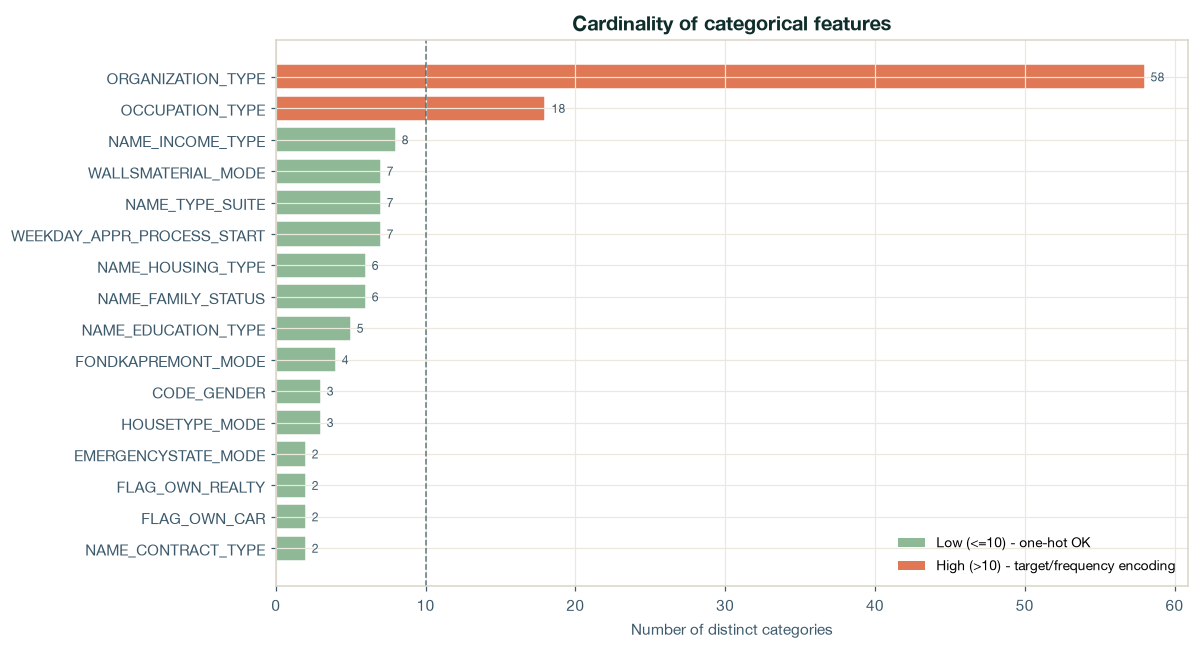

High-cardinality features (>10 categories):
  OCCUPATION_TYPE               : 18 categories
  ORGANIZATION_TYPE             : 58 categories


In [16]:
# Cardinality of each categorical feature
cardinality = train[cat_cols].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [CORAL if v > 10 else SAGE for v in cardinality.values]
bars = ax.barh(cardinality.index, cardinality.values, color=colors, edgecolor='white')
ax.axvline(x=10, color=SLATE, linestyle='--', alpha=0.8, linewidth=1,
           label='One-hot threshold (10)')
ax.set_xlabel('Number of distinct categories')
ax.set_title('Cardinality of categorical features', fontsize=13)
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend = [Patch(facecolor=SAGE,  label='Low (<=10) - one-hot OK'),
          Patch(facecolor=CORAL, label='High (>10) - target/frequency encoding')]
ax.legend(handles=legend, fontsize=9, loc='lower right')

for bar, v in zip(bars, cardinality.values):
    ax.text(v + 0.4, bar.get_y() + bar.get_height()/2, str(v),
            va='center', fontsize=8, color=SLATE)
plt.tight_layout()
plt.savefig('../data/08_reporting/categorical_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

print('High-cardinality features (>10 categories):')
for col, n in cardinality[cardinality > 10].items():
    print(f'  {col:30s}: {n} categories')

### 6.2 Categorical anomalies

Before trusting the categories, we check for invalid or placeholder values. `CODE_GENDER` reported 3 distinct values where only 2 are expected — a classic sign of a placeholder (`XNA`) that must be handled in cleaning.

In [17]:
# Inspect categories that may contain placeholders / anomalies
print('CODE_GENDER value counts:')
print(train['CODE_GENDER'].value_counts())
print()

# Flag the XNA placeholder if present
xna_gender = (train['CODE_GENDER'] == 'XNA').sum()
if xna_gender > 0:
    print(f'>> CODE_GENDER has {xna_gender} "XNA" placeholder rows -> treat as missing in cleaning.')
print()

# Generic anomaly scan: any category that looks like a placeholder
placeholder_tokens = ['XNA', 'XAP', 'Unknown', 'unknown', 'nan', 'NA', '']
print('Placeholder-like categories found across categorical features:')
found_any = False
for col in cat_cols:
    vals = train[col].dropna().unique()
    hits = [v for v in vals if str(v).strip() in placeholder_tokens]
    if hits:
        found_any = True
        for h in hits:
            n = (train[col] == h).sum()
            print(f'  {col:28s}: "{h}" -> {n:,} rows')
if not found_any:
    print('  none beyond CODE_GENDER')

CODE_GENDER value counts:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

>> CODE_GENDER has 4 "XNA" placeholder rows -> treat as missing in cleaning.

Placeholder-like categories found across categorical features:
  CODE_GENDER                 : "XNA" -> 4 rows
  NAME_FAMILY_STATUS          : "Unknown" -> 2 rows
  ORGANIZATION_TYPE           : "XNA" -> 55,374 rows


### 6.3 Default rate per category

For each categorical feature we compute the **default rate per category** against the global average (~8.1%), surfacing which groups carry above-average risk.

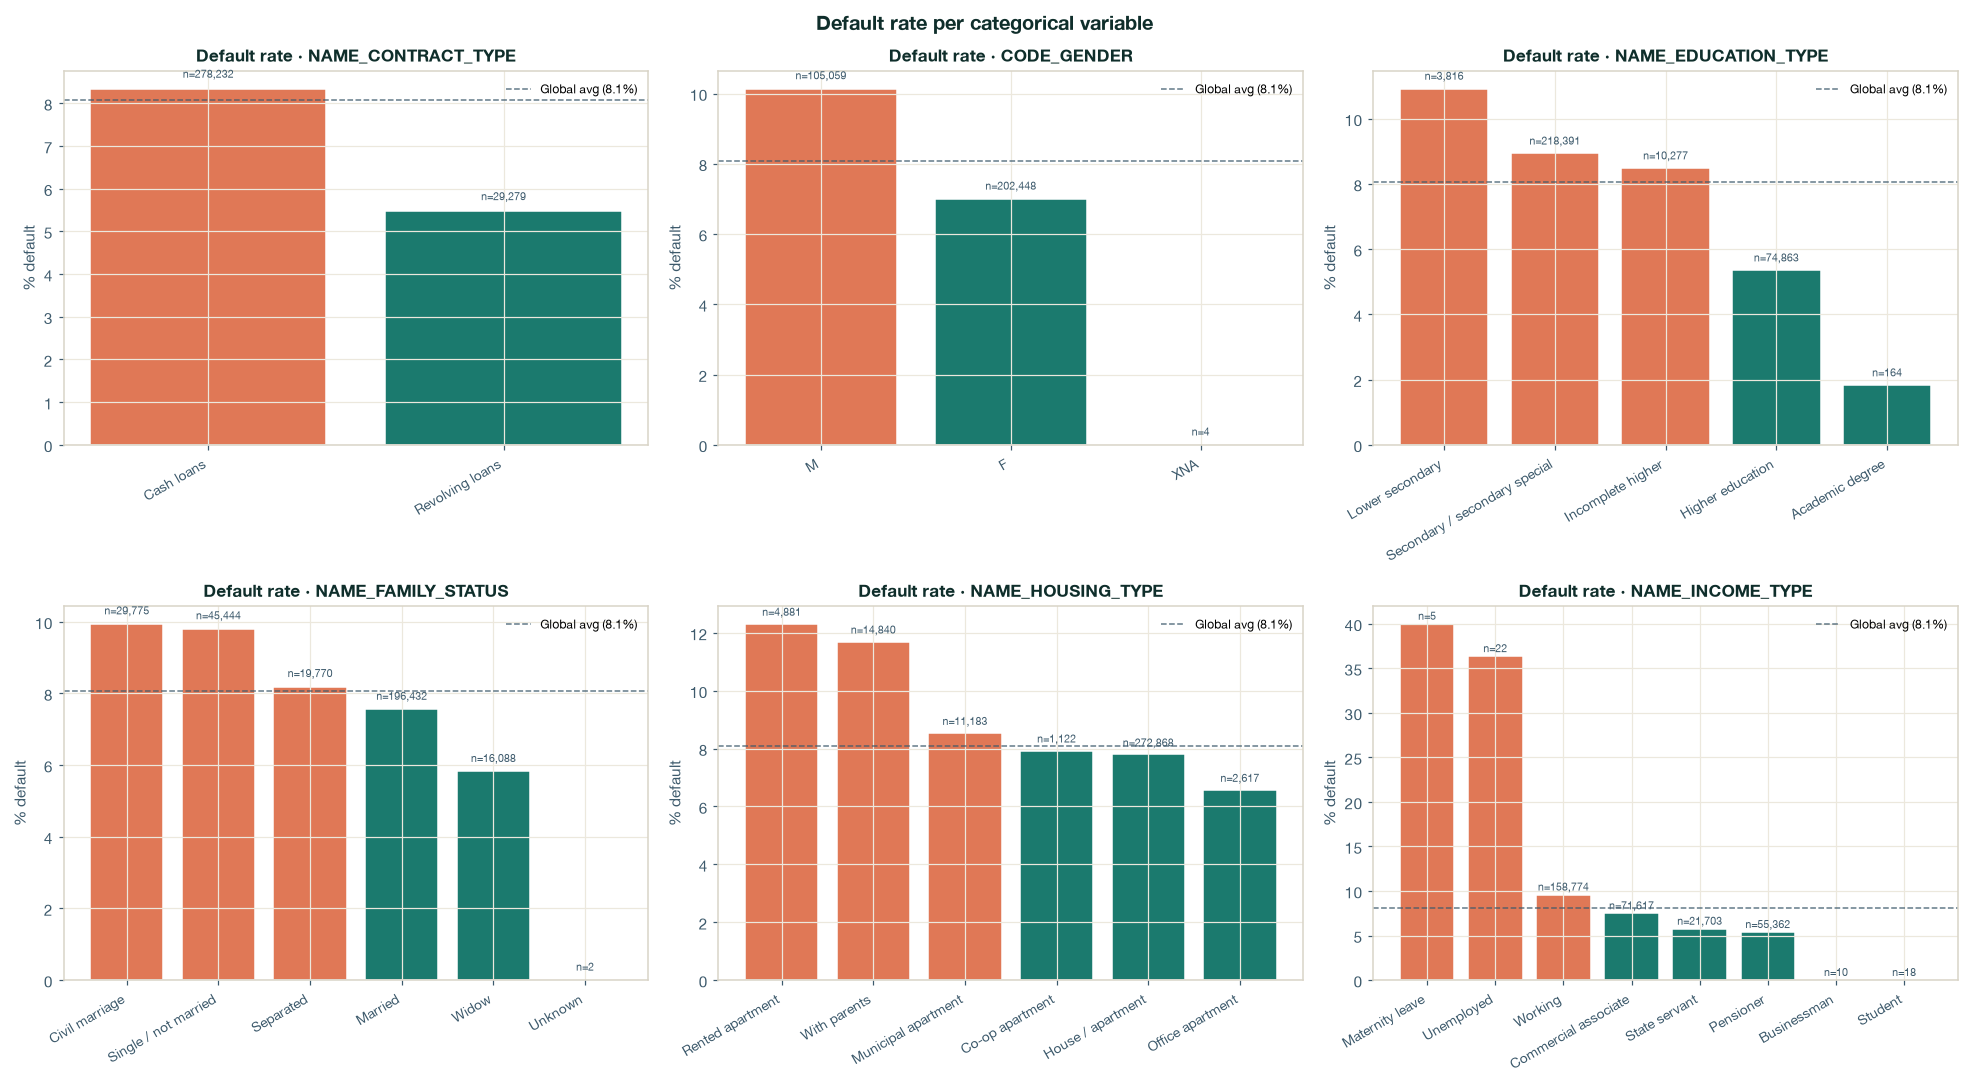

In [18]:
# Default rate by category — the most informative ones
key_cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
                'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE']
key_cat_cols = [c for c in key_cat_cols if c in train.columns]

global_rate = train['TARGET'].mean() * 100
n_cols = 3
n_rows = (len(key_cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_cat_cols):
    default_rate = train.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    count_map    = train[col].value_counts()

    bars = axes[i].bar(range(len(default_rate)), default_rate.values * 100,
                       color=[CORAL if v*100 > global_rate else TEAL for v in default_rate.values],
                       edgecolor='white')
    axes[i].set_xticks(range(len(default_rate)))
    axes[i].set_xticklabels(default_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Default rate · {col}', fontsize=11)
    axes[i].set_ylabel('% default')
    axes[i].axhline(y=global_rate, color=SLATE, linestyle='--', alpha=0.8,
                    linewidth=1, label=f'Global avg ({global_rate:.1f}%)')
    axes[i].legend(fontsize=8)
    for bar, cat in zip(bars, default_rate.index):
        n = count_map.get(cat, 0)
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'n={n:,}', ha='center', va='bottom', fontsize=7, color=SLATE)

for j in range(len(key_cat_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Default rate per categorical variable', fontsize=13, fontweight='bold', color=INK)
plt.tight_layout()
plt.savefig('../data/08_reporting/default_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

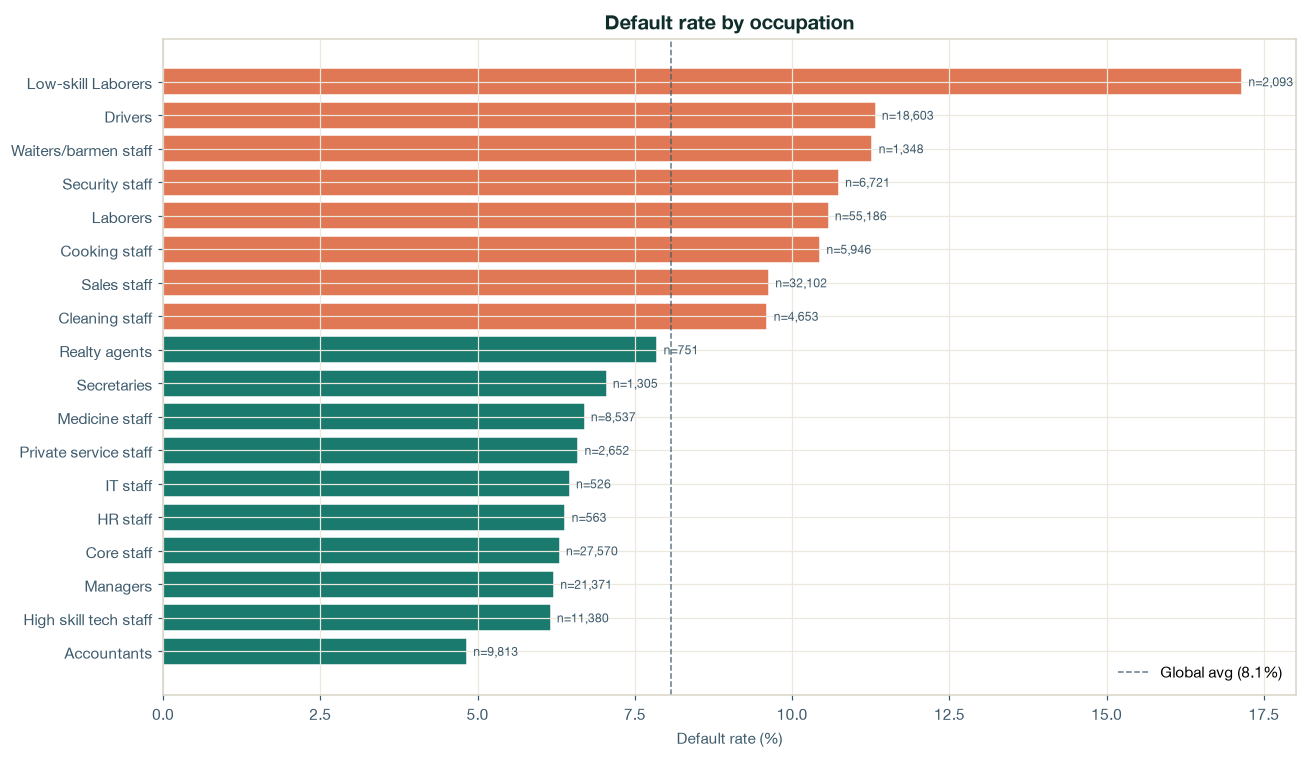

In [19]:
# Default rate by occupation
if 'OCCUPATION_TYPE' in train.columns:
    global_rate = train['TARGET'].mean() * 100
    occ = train.groupby('OCCUPATION_TYPE')['TARGET'].agg(['mean','count']).reset_index()
    occ.columns = ['occupation', 'default_rate', 'count']
    occ = occ.sort_values('default_rate', ascending=True)
    occ['default_pct'] = occ['default_rate'] * 100

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = [CORAL if v > global_rate else TEAL for v in occ['default_pct']]
    bars = ax.barh(occ['occupation'], occ['default_pct'], color=colors, edgecolor='white')
    ax.axvline(x=global_rate, color=SLATE, linestyle='--', alpha=0.8,
               linewidth=1, label=f'Global avg ({global_rate:.1f}%)')
    ax.set_xlabel('Default rate (%)')
    ax.set_title('Default rate by occupation', fontsize=13)
    ax.legend()
    for bar, n in zip(bars, occ['count']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={n:,}', va='center', fontsize=8, color=SLATE)
    plt.tight_layout()
    plt.savefig('../data/08_reporting/default_rate_by_occupation.png', dpi=150, bbox_inches='tight')
    plt.show()

<a id="correlations"></a>
## 7. Correlations

Which features move with default? We rank linear correlations with `TARGET` and examine how the strongest features relate to one another. Note that linear correlation only captures monotonic relationships — tree-based models may still exploit features that look weak here.

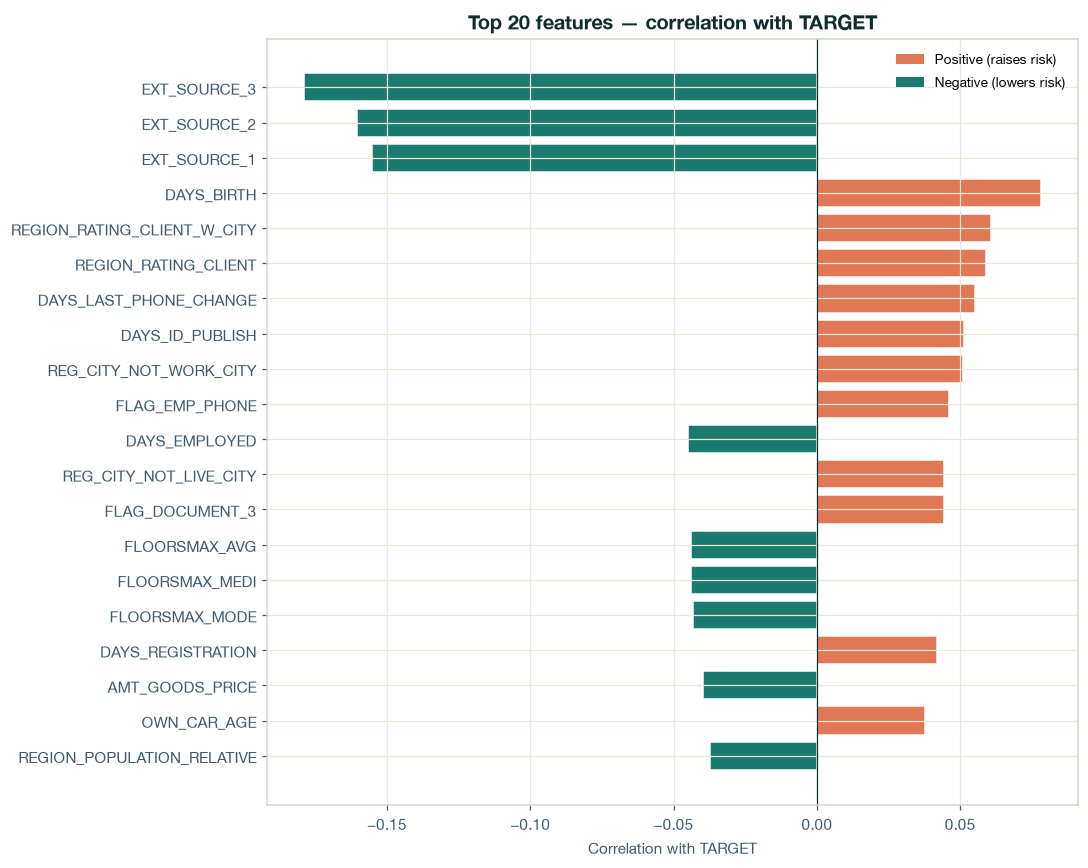

Top 10 features most correlated with default:
  EXT_SOURCE_3                       : -0.1789  (risk down)
  EXT_SOURCE_2                       : -0.1605  (risk down)
  EXT_SOURCE_1                       : -0.1553  (risk down)
  DAYS_BIRTH                         : +0.0782  (risk up)
  REGION_RATING_CLIENT_W_CITY        : +0.0609  (risk up)
  REGION_RATING_CLIENT               : +0.0589  (risk up)
  DAYS_LAST_PHONE_CHANGE             : +0.0552  (risk up)
  DAYS_ID_PUBLISH                    : +0.0515  (risk up)
  REG_CITY_NOT_WORK_CITY             : +0.0510  (risk up)
  FLAG_EMP_PHONE                     : +0.0460  (risk up)


In [20]:
# Correlation with TARGET — top features
corr_target = train[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').dropna()
corr_target_sorted = corr_target.abs().sort_values(ascending=False).head(20)
top_corr = corr_target[corr_target_sorted.index]

fig, ax = plt.subplots(figsize=(10, 8))
colors = [CORAL if v > 0 else TEAL for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
ax.axvline(x=0, color=INK, linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Top 20 features — correlation with TARGET', fontsize=13)

from matplotlib.patches import Patch
legend = [Patch(facecolor=CORAL, label='Positive (raises risk)'),
          Patch(facecolor=TEAL,  label='Negative (lowers risk)')]
ax.legend(handles=legend, fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/08_reporting/correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features most correlated with default:')
for feat, val in top_corr.head(10).items():
    direction = 'risk up' if val > 0 else 'risk down'
    print(f'  {feat:35s}: {val:+.4f}  ({direction})')

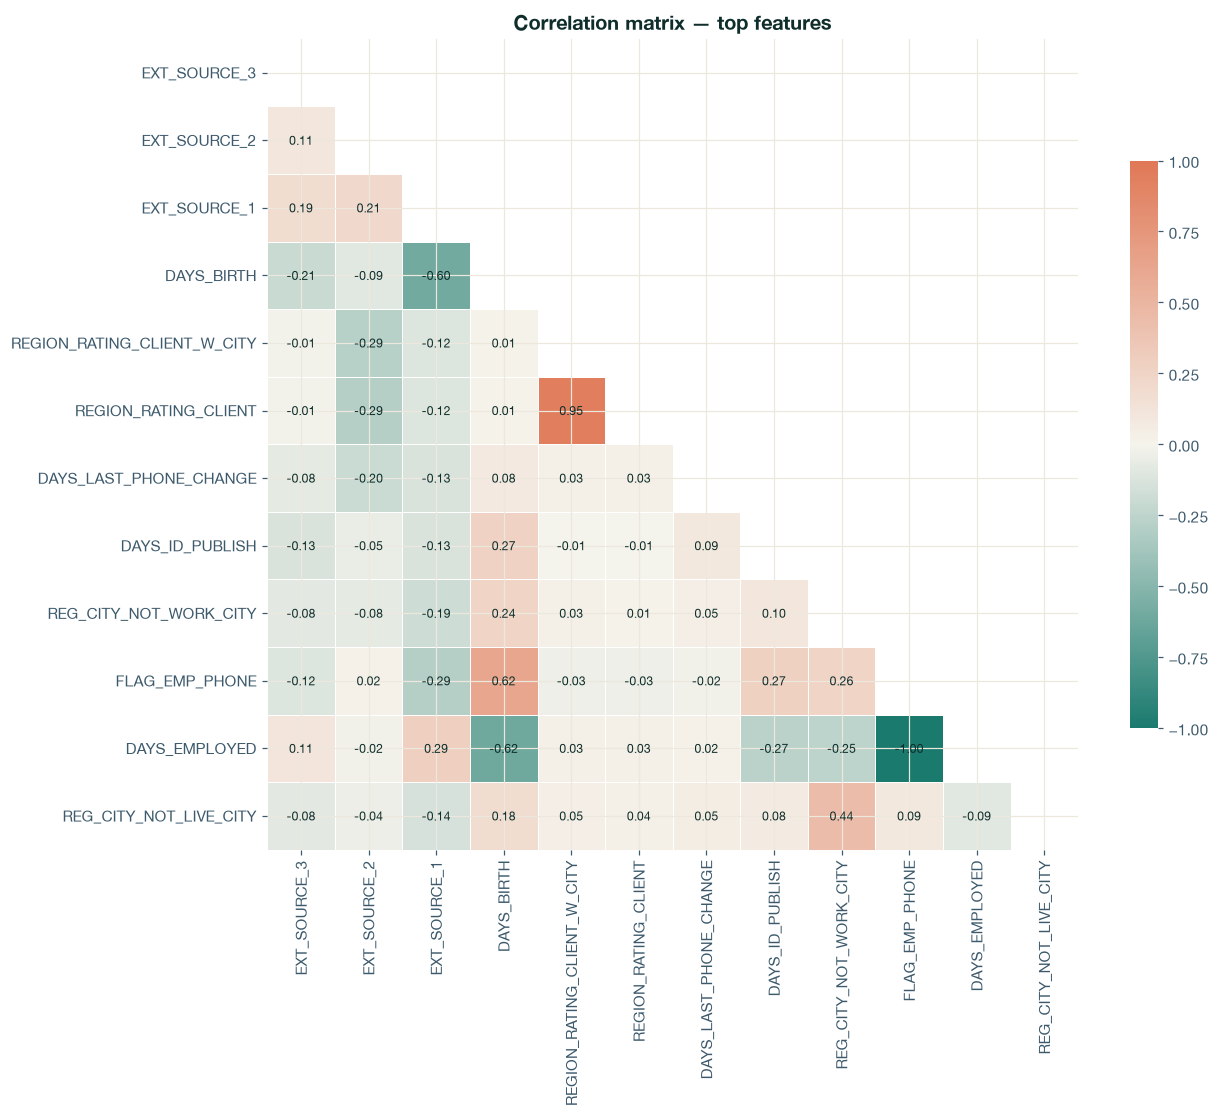

In [21]:
# Correlation matrix of the top features
top_features = corr_target.abs().sort_values(ascending=False).head(12).index.tolist()
corr_matrix  = train[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8, 'color': INK})
ax.set_title('Correlation matrix — top features', fontsize=13)
plt.tight_layout()
plt.savefig('../data/08_reporting/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="multicollinearity"></a>
## 8. Multicollinearity

The missing-value analysis revealed that many building-related features come in `_AVG` / `_MODE` / `_MEDI` triplets describing the same underlying quantity. These are almost perfectly correlated with one another and add redundancy that hurts linear models and distorts feature-importance interpretation.

Here we identify **highly correlated feature pairs** (|r| > 0.9) so the cleaning/feature-engineering stage can drop or collapse the redundant ones.

In [22]:
# Find highly correlated numerical feature pairs (|r| > 0.9)
THRESHOLD = 0.9

# Use the full numerical correlation matrix
num_corr = train[num_cols].corr().abs()

# Keep only the upper triangle to avoid duplicate pairs
upper = num_corr.where(np.triu(np.ones(num_corr.shape, dtype=bool), k=1))

# Extract pairs above threshold
high_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
)
high_pairs = high_pairs[high_pairs['abs_corr'] > THRESHOLD].sort_values('abs_corr', ascending=False)

print(f'Highly correlated pairs (|r| > {THRESHOLD}): {len(high_pairs)}')
print()
print(high_pairs.head(25).to_string(index=False))

# Columns that are redundant (appear as feature_2 in a high-corr pair)
redundant = sorted(set(high_pairs['feature_2']))
print(f'\nCandidate redundant columns to drop: {len(redundant)}')

Highly correlated pairs (|r| > 0.9): 62

                  feature_1                    feature_2  abs_corr
              DAYS_EMPLOYED               FLAG_EMP_PHONE      1.00
            YEARS_BUILD_AVG             YEARS_BUILD_MEDI      1.00
   OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE      1.00
              FLOORSMIN_AVG               FLOORSMIN_MEDI      1.00
              FLOORSMAX_AVG               FLOORSMAX_MEDI      1.00
              ENTRANCES_AVG               ENTRANCES_MEDI      1.00
              ELEVATORS_AVG               ELEVATORS_MEDI      1.00
             COMMONAREA_AVG              COMMONAREA_MEDI      1.00
             LIVINGAREA_AVG              LIVINGAREA_MEDI      1.00
             APARTMENTS_AVG              APARTMENTS_MEDI      1.00
           BASEMENTAREA_AVG            BASEMENTAREA_MEDI      0.99
       LIVINGAPARTMENTS_AVG        LIVINGAPARTMENTS_MEDI      0.99
YEARS_BEGINEXPLUATATION_AVG YEARS_BEGINEXPLUATATION_MEDI      0.99
               LANDAR

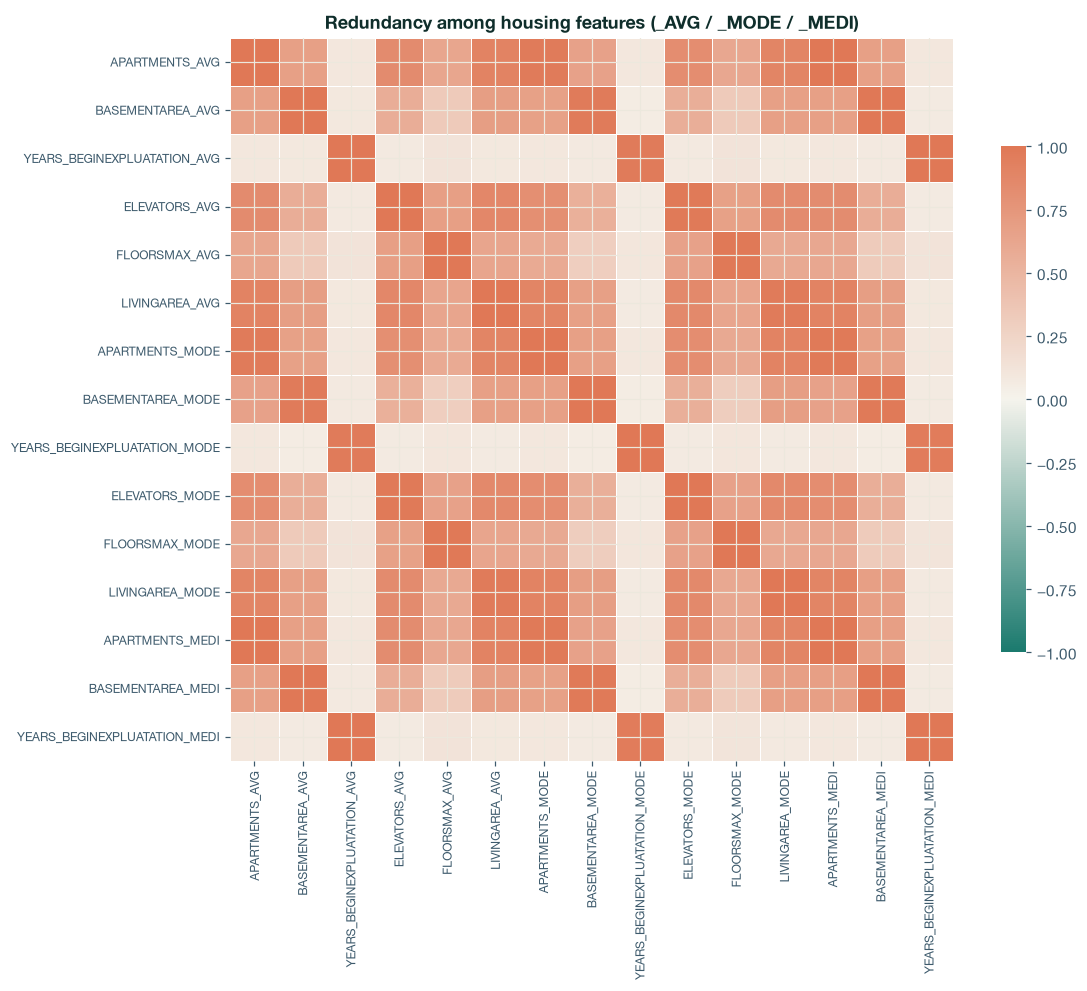

The block-diagonal pattern confirms each measurement is repeated 3x (AVG/MODE/MEDI).


In [23]:
# Visualize the correlation block among the housing _AVG/_MODE/_MEDI features
housing_cols = [c for c in num_cols if any(
    c.endswith(suf) for suf in ['_AVG', '_MODE', '_MEDI'])]

# Take a readable subset to illustrate the redundancy
subset = [c for c in housing_cols if c.startswith(('APARTMENTS', 'BASEMENTAREA',
          'YEARS_BEGINEXPLUATATION', 'ELEVATORS', 'FLOORSMAX', 'LIVINGAREA'))]
subset = subset[:15]

if subset:
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(train[subset].corr(), annot=False, cmap=CMAP_DIV, center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.7}, ax=ax)
    ax.set_title('Redundancy among housing features (_AVG / _MODE / _MEDI)', fontsize=12)
    plt.xticks(fontsize=8); plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig('../data/08_reporting/multicollinearity_housing.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('The block-diagonal pattern confirms each measurement is repeated 3x (AVG/MODE/MEDI).')

<a id="leakage"></a>
## 9. Data leakage & sanity checks

In a credit-risk setting, **data leakage** means using information that would not be available at the moment the loan decision is made. A leaked feature inflates offline performance but fails in production. We run a few sanity checks to confirm the features are decision-time safe.

- **9.1 Train/test schema parity** — every feature used in training must also exist at scoring time.
- **9.2 Suspicious near-perfect predictors** — any single feature with an implausibly high correlation to `TARGET` is a red flag.
- **9.3 Logical range checks** — values that are physically impossible (negative income, future birth dates) signal data issues, not signal.

### 9.1 Train/test schema parity

In [24]:
train_feats = set(train.columns) - {'TARGET'}
test_feats  = set(test.columns)
only_in_train = train_feats - test_feats
only_in_test  = test_feats - train_feats

print('9.1 SCHEMA PARITY')
print(f'  Features only in train (excl. TARGET): {only_in_train if only_in_train else "none"}')
print(f'  Features only in test               : {only_in_test if only_in_test else "none"}')
print('  -> If non-empty (beyond engineered cols), those features cannot be used at scoring time.')

9.1 SCHEMA PARITY
  Features only in train (excl. TARGET): {'DAYS_EMPLOYED_CLEAN', 'AGE_YEARS', 'EMPLOYED_YEARS'}
  Features only in test               : none
  -> If non-empty (beyond engineered cols), those features cannot be used at scoring time.


### 9.2 Suspicious near-perfect predictors

In [25]:
abs_corr_target = train[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').abs()
suspicious = abs_corr_target[abs_corr_target > 0.5].sort_values(ascending=False)

print('9.2 NEAR-PERFECT PREDICTORS (|corr| > 0.5)')
if len(suspicious) == 0:
    print('  None - no single feature trivially predicts the target (healthy sign).')
else:
    print(suspicious.to_string())
    print('  -> Investigate: a single very strong predictor often indicates leakage.')

9.2 NEAR-PERFECT PREDICTORS (|corr| > 0.5)
  None - no single feature trivially predicts the target (healthy sign).


### 9.3 Logical range checks

In [26]:
checks = {
    'AMT_INCOME_TOTAL <= 0'    : (train['AMT_INCOME_TOTAL'] <= 0).sum(),
    'AMT_CREDIT <= 0'          : (train['AMT_CREDIT'] <= 0).sum(),
    'DAYS_BIRTH >= 0 (future)' : (train['DAYS_BIRTH'] >= 0).sum(),
    'CNT_CHILDREN < 0'         : (train['CNT_CHILDREN'] < 0).sum(),
    'DAYS_EMPLOYED == 365243'  : (train['DAYS_EMPLOYED'] == 365243).sum(),
}
for label, count in checks.items():
    status = 'OK' if (count == 0 or 'EMPLOYED' in label) else 'CHECK'
    print(f'  [{status:5s}] {label:32s}: {count:,} rows')

  [OK   ] AMT_INCOME_TOTAL <= 0           : 0 rows
  [OK   ] AMT_CREDIT <= 0                 : 0 rows
  [OK   ] DAYS_BIRTH >= 0 (future)        : 0 rows
  [OK   ] CNT_CHILDREN < 0                : 0 rows
  [OK   ] DAYS_EMPLOYED == 365243         : 55,374 rows


<a id="secondary"></a>
## 10. Secondary tables analysis

The real signal often lives in the auxiliary tables. We aggregate `bureau` and `previous_application` per client and check whether the engineered features correlate with default.

In [27]:
# Load secondary tables
import os

secondary_files = {
    'bureau'               : 'bureau.csv',
    'previous_application' : 'previous_application.csv',
    'bureau_balance'       : 'bureau_balance.csv',
    'pos_cash'             : 'POS_CASH_balance.csv',
    'installments'         : 'installments_payments.csv',
    'credit_card'          : 'credit_card_balance.csv',
}

tables = {}
for name, fname in secondary_files.items():
    fpath = DATA_PATH + fname
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        tables[name] = df
        print(f'  {name:25s}: {df.shape[0]:>10,} rows × {df.shape[1]:>3} columns')
    else:
        print(f'  {name:25s}: file not found')

  bureau                   :  1,716,428 rows ×  17 columns
  previous_application     :  1,670,214 rows ×  37 columns
  bureau_balance           : 27,299,925 rows ×   3 columns
  pos_cash                 : 10,001,358 rows ×   8 columns
  installments             : 13,605,401 rows ×   8 columns
  credit_card              :  3,840,312 rows ×  23 columns


In [28]:
# --- BUREAU ---
if 'bureau' in tables:
    bureau = tables['bureau']
    
    print('=== BUREAU ===')
    print(f'Unique clients: {bureau["SK_ID_CURR"].nunique():,}')
    print(f'Credits per client (average): {bureau.groupby("SK_ID_CURR").size().mean():.1f}')
    print(f'\nCredit status (CREDIT_ACTIVE):')
    print(bureau['CREDIT_ACTIVE'].value_counts())
    
    # Aggregate useful features per client
    bureau_agg = bureau.groupby('SK_ID_CURR').agg(
        bureau_n_credits        = ('SK_ID_BUREAU', 'count'),
        bureau_n_active         = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
        bureau_n_closed         = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
        bureau_avg_credit_day   = ('DAYS_CREDIT', 'mean'),
        bureau_total_debt       = ('AMT_CREDIT_SUM_DEBT', 'sum'),
        bureau_total_credit     = ('AMT_CREDIT_SUM', 'sum'),
        bureau_n_prolonged      = ('CNT_CREDIT_PROLONG', 'sum'),
    ).reset_index()
    
    # Merge with train and check correlations
    train_bureau = train[['SK_ID_CURR', 'TARGET']].merge(bureau_agg, on='SK_ID_CURR', how='left')
    
    bureau_corr = train_bureau.corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)
    print(f'\nCorrelation of bureau features with TARGET:')
    print(bureau_corr.head(7).to_string())

=== BUREAU ===
Unique clients: 305,811
Credits per client (average): 5.6

Credit status (CREDIT_ACTIVE):
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

Correlation of bureau features with TARGET:
bureau_avg_credit_day    0.09
bureau_n_active          0.07
bureau_n_closed         -0.03
bureau_total_credit     -0.01
bureau_total_debt        0.01
bureau_n_prolonged       0.00
bureau_n_credits         0.00


In [29]:
# --- PREVIOUS APPLICATION ---
if 'previous_application' in tables:
    prev = tables['previous_application']
    
    print('=== PREVIOUS APPLICATION ===')
    print(f'Unique clients: {prev["SK_ID_CURR"].nunique():,}')
    print(f'Applications per client (average): {prev.groupby("SK_ID_CURR").size().mean():.1f}')
    print(f'\nApplication decision (NAME_CONTRACT_STATUS):')
    print(prev['NAME_CONTRACT_STATUS'].value_counts())
    
    # Refusal rate — powerful feature!
    prev_agg = prev.groupby('SK_ID_CURR').agg(
        prev_n_applications = ('SK_ID_PREV', 'count'),
        prev_n_approved     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
        prev_n_refused      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
        prev_n_cancelled    = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
        prev_avg_credit     = ('AMT_CREDIT', 'mean'),
        prev_avg_annuity    = ('AMT_ANNUITY', 'mean'),
    ).reset_index()
    prev_agg['prev_refusal_rate'] = prev_agg['prev_n_refused'] / prev_agg['prev_n_applications']
    
    train_prev = train[['SK_ID_CURR', 'TARGET']].merge(prev_agg, on='SK_ID_CURR', how='left')
    
    prev_corr = train_prev.corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)
    print(f'\nCorrelation of previous_application features with TARGET:')
    print(prev_corr.head(7).to_string())

=== PREVIOUS APPLICATION ===
Unique clients: 338,857
Applications per client (average): 4.9

Application decision (NAME_CONTRACT_STATUS):
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

Correlation of previous_application features with TARGET:
prev_refusal_rate      0.08
prev_n_refused         0.06
prev_avg_annuity      -0.03
prev_n_approved       -0.03
prev_n_applications    0.02
prev_n_cancelled       0.02
prev_avg_credit       -0.02


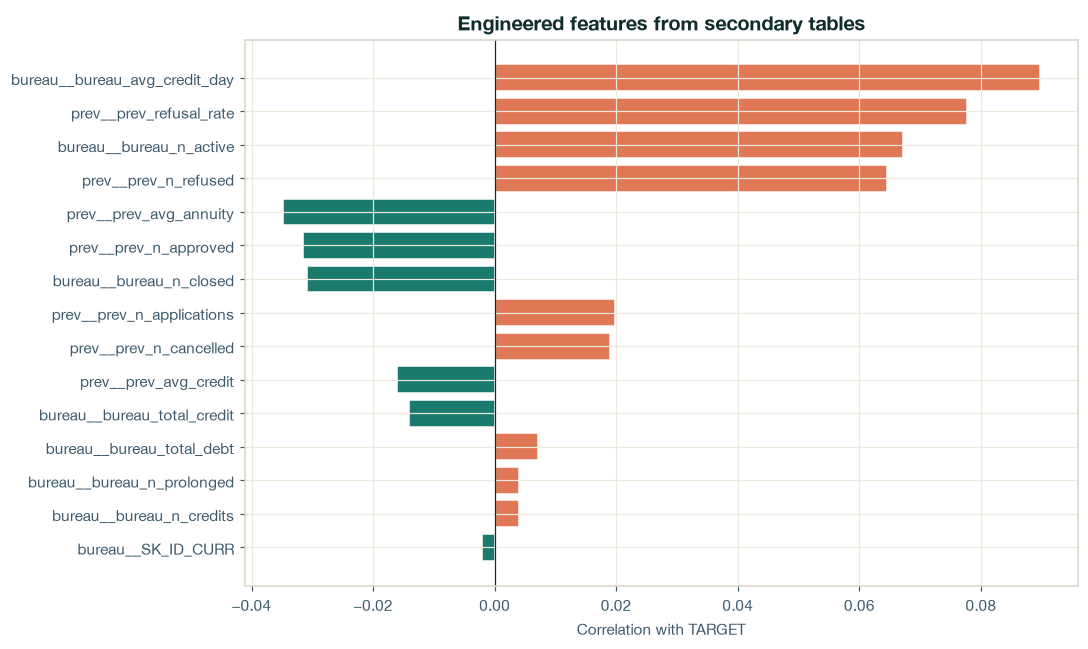

In [30]:
# Correlations of all engineered secondary-table features
all_secondary_corrs = {}
if 'bureau' in tables:
    for col in bureau_corr.index:
        all_secondary_corrs[f'bureau__{col}'] = bureau_corr[col]
if 'previous_application' in tables:
    for col in prev_corr.index:
        all_secondary_corrs[f'prev__{col}'] = prev_corr[col]

if all_secondary_corrs:
    sec = pd.Series(all_secondary_corrs).sort_values(key=abs, ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [CORAL if v > 0 else TEAL for v in sec.values]
    ax.barh(sec.index, sec.values, color=colors, edgecolor='white')
    ax.axvline(x=0, color=INK, linewidth=0.8)
    ax.set_xlabel('Correlation with TARGET')
    ax.set_title('Engineered features from secondary tables', fontsize=13)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../data/08_reporting/secondary_tables_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

<a id="conclusions"></a>
## 11. Conclusions & decisions for the pipeline


A consolidated summary of every decision the EDA surfaced — target strategy, data-quality rules, cleaning steps, multicollinearity, leakage checks and the most promising features — ready to feed the next pipeline stage.

In [31]:
print('=' * 68)
print('EDA SUMMARY - PIPELINE DECISIONS')
print('=' * 68)
# A ALTERAR APOS ANALISE DE EDA 
print('''
1. TARGET
   - Imbalanced classes: ~91.9% paid vs ~8.1% default (ratio 11.4:1)
   - Metrics: AUC-ROC (primary), F1 / Precision-Recall (secondary)
   - Strategy: class_weight="balanced" or SMOTE during training

2. DATA QUALITY (Great Expectations)
   - DAYS_EMPLOYED: sentinel 365243 (18% of rows) -> replace with NaN
   - CODE_GENDER: "XNA" placeholder -> treat as missing
   - Expect: AMT_INCOME_TOTAL > 0
   - Expect: DAYS_BIRTH < 0 (negative days = past)
   - Expect: TARGET in {0, 1}
   - Expect: SK_ID_CURR unique per row

3. DATA CLEANING
   - Replace DAYS_EMPLOYED = 365243 with NaN
   - Replace CODE_GENDER = "XNA" with NaN
   - Drop columns with >60% missing (17 housing columns)
   - Imputation: numerical -> median; categorical -> mode

4. MULTICOLLINEARITY
   - Housing features come in _AVG/_MODE/_MEDI triplets (|r| > 0.9)
   - Collapse each triplet to a single representation (keep _MEDI)
   - Reduces dimensionality and stabilizes linear models

5. CATEGORICAL ENCODING
   - Low cardinality (<=10): one-hot encoding
   - High cardinality (ORGANIZATION_TYPE=58, OCCUPATION_TYPE=18):
     target or frequency encoding

6. DATA LEAKAGE
   - Train/test schema parity confirmed (only TARGET differs)
   - No single feature trivially predicts target (no leakage signal)
   - All features are decision-time safe

7. FEATURE ENGINEERING
   - CREDIT_INCOME_RATIO  = AMT_CREDIT / AMT_INCOME_TOTAL
   - ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL
   - AGE_YEARS            = -DAYS_BIRTH / 365
   - EMPLOYED_YEARS       = -DAYS_EMPLOYED_CLEAN / 365
   - EXT_SOURCE_MEAN      = mean of the 3 EXT_SOURCE
   - Aggregate bureau and previous_application per client

8. MOST PROMISING FEATURES
   - EXT_SOURCE_1/2/3  <- strongest predictors
   - DAYS_BIRTH (age), DAYS_EMPLOYED
   - AMT_CREDIT, AMT_ANNUITY
   - prev_refusal_rate (engineered from previous_application)
   - NOTE: secondary-table features show weak linear correlation
     (~0.08), but may still help tree-based models via interactions

9. SUGGESTED BASELINE MODEL
   - Logistic Regression (interpretable baseline)
   - LightGBM / XGBoost (strong model, handles NaN natively)
   - Evaluate with class_weight="balanced"
''')

print('=' * 68)

EDA SUMMARY - PIPELINE DECISIONS

1. TARGET
   - Imbalanced classes: ~91.9% paid vs ~8.1% default (ratio 11.4:1)
   - Metrics: AUC-ROC (primary), F1 / Precision-Recall (secondary)
   - Strategy: class_weight="balanced" or SMOTE during training

2. DATA QUALITY (Great Expectations)
   - DAYS_EMPLOYED: sentinel 365243 (18% of rows) -> replace with NaN
   - CODE_GENDER: "XNA" placeholder -> treat as missing
   - Expect: AMT_INCOME_TOTAL > 0
   - Expect: DAYS_BIRTH < 0 (negative days = past)
   - Expect: TARGET in {0, 1}
   - Expect: SK_ID_CURR unique per row

3. DATA CLEANING
   - Replace DAYS_EMPLOYED = 365243 with NaN
   - Replace CODE_GENDER = "XNA" with NaN
   - Drop columns with >60% missing (17 housing columns)
   - Imputation: numerical -> median; categorical -> mode

4. MULTICOLLINEARITY
   - Housing features come in _AVG/_MODE/_MEDI triplets (|r| > 0.9)
   - Collapse each triplet to a single representation (keep _MEDI)
   - Reduces dimensionality and stabilizes linear models

5. 

In [32]:
# Save list of columns to drop (>60% missing)
cols_to_drop = missing[missing['missing_pct'] > 60].index.tolist()
print(f'Columns to consider removing (>60% missing): {len(cols_to_drop)}')
print(cols_to_drop)

# Save to use in the cleaning pipeline
import json
import os
os.makedirs('../conf/base', exist_ok=True)
with open('../conf/base/eda_decisions.json', 'w') as f:
    json.dump({
        'cols_to_drop_high_missing': cols_to_drop,
        'target_imbalance_ratio': round(float(target_counts[0]/target_counts[1]), 2),
        'n_train': int(train.shape[0]),
        'n_features_raw': int(train.shape[1])
    }, f, indent=2)

print('\n eda_decisions.json saved in conf/base/')

Columns to consider removing (>60% missing): 17
['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE']

 eda_decisions.json saved in conf/base/
